In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [36]:
data_train = pd.read_csv("train.csv")
df = data_train.copy()
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [38]:
df.drop("id", axis=1, inplace=True)

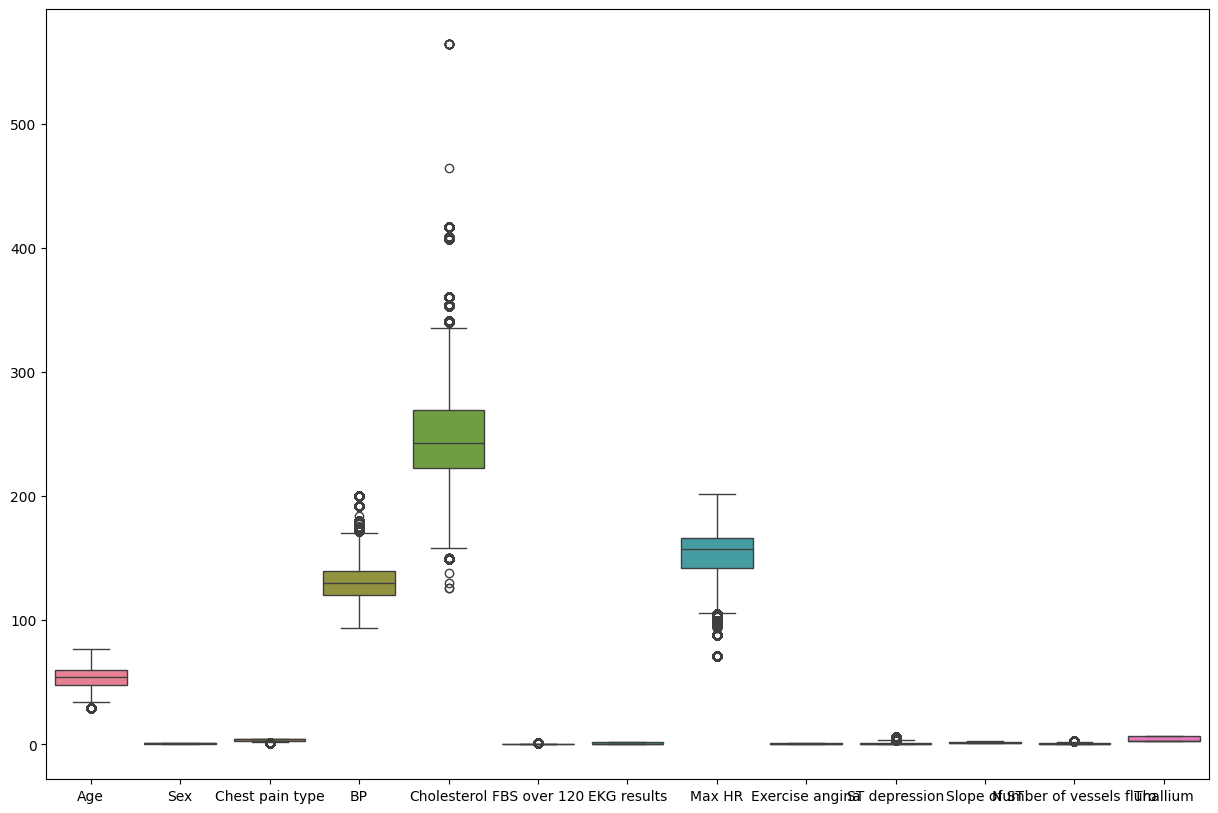

In [39]:
plt.figure(figsize=(15,10))
sns.boxplot(df)
plt.show()

In [40]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [107]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score, recall_score,roc_auc_score

In [91]:
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=10,criterion="entropy")

model.fit(X_train, y_train)

predict = model.predict(X_test)

In [59]:
predict

array(['Absence', 'Absence', 'Presence', ..., 'Absence', 'Presence',
       'Presence'], shape=(126000,), dtype=object)

In [93]:
f1_score(y_test, predict, pos_label='Presence')

0.8658398089940892

In [94]:
accuracy_score(y_test, predict)

0.8809285714285714

In [95]:
recall_score(y_test, predict, pos_label='Presence')

0.8578389680345878

In [96]:
df["Heart Disease"].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [99]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,max_depth=300,min_samples_split=5 ,random_state=42)
rf_model.fit(X_train, y_train)

rf_predict = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, rf_predict)}")
print(f"Recall (Повнота): {recall_score(y_test, rf_predict,pos_label='Presence')}")
print(f"F1 Score: {f1_score(y_test, rf_predict,pos_label='Presence')}")

Accuracy: 0.8815
Recall (Повнота): 0.8618789425189596
F1 Score: 0.8669405505600956


In [100]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200,max_depth=500,min_samples_split=10 ,random_state=42)
rf_model.fit(X_train, y_train)

rf_predict = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, rf_predict)}")
print(f"Recall (Повнота): {recall_score(y_test, rf_predict,pos_label='Presence')}")
print(f"F1 Score: {f1_score(y_test, rf_predict,pos_label='Presence')}")

Accuracy: 0.8833333333333333
Recall (Повнота): 0.8631547239350769
F1 Score: 0.8688974903233861


In [102]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder

In [113]:
le = LabelEncoder()
df['Heart Disease'] = le.fit_transform(df['Heart Disease'])

X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"Recall:   {recall_score(y_test, preds):.4f}")
    print(f"F1 Score: {f1_score(y_test, preds):.4f}")
    print(f"ROC_AUC: {roc_auc_score(y_test, preds):.4f}\n")


xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
evaluate_model(xgb, "XGBoost")

lgbm = LGBMClassifier(random_state=42, verbose=-1)
evaluate_model(lgbm, "LightGBM")

cat = CatBoostClassifier(verbose=0, random_state=42)
evaluate_model(cat, "CatBoost")

C:\Users\Дмитро\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:41:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
Accuracy: 0.8870
Recall:   0.8662
F1 Score: 0.8729
ROC_AUC: 0.8850

--- LightGBM ---
Accuracy: 0.8867
Recall:   0.8662
F1 Score: 0.8726
ROC_AUC: 0.8848

--- CatBoost ---
Accuracy: 0.8871
Recall:   0.8662
F1 Score: 0.8730
ROC_AUC: 0.8851

